In [ ]:
# # Volatility-Managed Portfolio (Moreira & Muir, 2017) — S&P 500
# - Stratégie sans cap : w_t = c / RV_{t-1}
# - Stratégie cap 1.5 : w_t = min(w_t, 1.5)
# - RV_t = somme des rendements quotidiens^2 dans le mois t
# - c choisi pour que std(r_vm) = std(r_bh) (version sans cap)

# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import statsmodels.api as sm
from pathlib import Path
import yfinance as yf
import warnings
warnings.filterwarnings("ignore")

# %%
# --- Paramètres ---
ASSET_TICKER       = "^GSPC"
FF_DAILY_PATH      = Path("F-F_Research_Data_Factors_daily.csv")
USE_EXCESS_RETURNS = True
CAP                = 1.5
START_DATE         = "1926-07-01"

# %% [markdown]
# ## 1) Import S&P (daily) + rendements

# %%
# --- 1) Download asset robustly ---
data = yf.download(ASSET_TICKER, start=START_DATE, auto_adjust=True, progress=False)
close = data["Close"]
if isinstance(close, pd.DataFrame):
    close = close.iloc[:, 0]
px = close.dropna()

if px.empty:
    ASSET_TICKER = "SPY"
    data = yf.download(ASSET_TICKER, start=START_DATE, auto_adjust=True, progress=False)
    close = data["Close"]
    if isinstance(close, pd.DataFrame):
        close = close.iloc[:, 0]
    px = close.dropna()

asset_daily_ret = px.pct_change().dropna()
asset_daily_ret.name = "r_daily"

In [27]:
# ## 2) Import Fama-French daily (robuste) + conversion % -> décimal

# %%
lines = FF_DAILY_PATH.read_text(encoding="utf-8", errors="ignore").splitlines()

header_idx = None
for i, s in enumerate(lines):
    if s.strip().replace(" ", "") == ",Mkt-RF,SMB,HML,RF":
        header_idx = i
        break

if header_idx is None:
    raise ValueError("En-tête ',Mkt-RF,SMB,HML,RF' introuvable.")

ff = pd.read_csv(FF_DAILY_PATH, skiprows=header_idx)
ff = ff.rename(columns={ff.columns[0]: "Date", "Mkt-RF": "MktRF"})
ff["Date"] = ff["Date"].astype(str).str.strip()
ff = ff[ff["Date"].str.fullmatch(r"\d{8}")].copy()
ff["Date"] = pd.to_datetime(ff["Date"], format="%Y%m%d")
ff = ff.set_index("Date").sort_index()

ff_daily = ff[["MktRF", "SMB", "HML", "RF"]].apply(pd.to_numeric, errors="coerce") / 100.0
ff_daily = ff_daily.dropna()

display(ff_daily.head())
print("Période:", ff_daily.index.min().date(), "->", ff_daily.index.max().date(),
      " | shape:", ff_daily.shape)

,MktRF,SMB,HML,RF
Date,,,,
1926-07-01,0.0009,-0.0025,-0.0027,0.0001
1926-07-02,0.0045,-0.0033,-0.0006,0.0001
1926-07-06,0.0017,0.0030,-0.0039,0.0001
1926-07-07,0.0009,-0.0058,0.0002,0.0001
1926-07-08,0.0022,-0.0038,0.0019,0.0001


Période: 1926-07-01 -> 2025-12-31  | shape: (26151, 4)


In [ ]:
# ## 3) Alignement des séries + rendements excédentaires journaliers

# %%
# Align on common dates
common_idx      = asset_daily_ret.index.intersection(ff_daily.index)
r_d             = asset_daily_ret.loc[common_idx].copy()
rf_d            = ff_daily.loc[common_idx, "RF"].copy()

# Excess daily return  (used for RV² computation and monthly f)
r_d_excess      = r_d - rf_d
r_d_excess.name = "r_excess_daily"

print(f"Dates communes : {len(common_idx)}  "
      f"({common_idx.min().date()} → {common_idx.max().date()})")

Dates communes : 24616  (1928-01-03 → 2025-12-31)


In [ ]:
# ## 4) Agrégation mensuelle
#
# - **f_t** : rendement excédentaire mensuel cumulé = produit des (1 + r_exc_daily) − 1
# - **RV²_t** : variance réalisée = Σ r²_{daily,exc} sur le mois t  (Eq. 2 du papier)
# - **RF_t** : taux sans risque mensuel cumulé
# %%
daily_df       = pd.DataFrame({"r": r_d, "r_exc": r_d_excess, "RF": rf_d})
daily_df["ym"] = daily_df.index.to_period("M")

# Monthly compound excess return  → factor f
monthly_f = (
    daily_df.groupby("ym")["r_exc"]
    .apply(lambda x: (1 + x).prod() - 1)
    .rename("f")
)

# Monthly compound RF
monthly_rf = (
    daily_df.groupby("ym")["RF"]
    .apply(lambda x: (1 + x).prod() - 1)
    .rename("RF")
)

# Realised variance (Eq. 2):  RV²_t = Σ_{d in t} r²_{d,exc}
# Note: paper uses raw squared daily excess returns (not demeaned)
monthly_rv2 = (
    daily_df.groupby("ym")["r_exc"]
    .apply(lambda x: (x ** 2).sum())
    .rename("RV2")
)

monthly = pd.DataFrame({"f": monthly_f, "RF": monthly_rf, "RV2": monthly_rv2})
monthly = monthly.dropna()

print(f"Mensuel : {len(monthly)} observations  "
      f"({monthly.index.min()} → {monthly.index.max()})")
monthly.describe()



Mensuel : 1176 observations  (1928-01 → 2025-12)


,f,RF,RV2
count,1176.000000,1176.000000,1176.000000
mean,0.003900,0.002608,0.002981
std,0.053386,0.002617,0.006006
min,-0.299423,0.000000,0.000070
25%,-0.021911,0.000000,0.000718
50%,0.007220,0.002102,0.001313
75%,0.032911,0.004208,0.002536
max,0.391376,0.013283,0.073173


In [ ]:
#  5) Construction des portefeuilles gérés par la volatilité
# **Eq. 1 (Moreira & Muir):**
# $$f^\sigma_{t+1} = \frac{c}{\widehat\sigma^2_t} \cdot f_{t+1}
#   \quad \text{avec} \quad \widehat\sigma^2_t = RV^2_t$$
#
# Signal = variance réalisée du mois **précédent** (connue en début de mois t+1).
# Constante `c` : normalise pour que std(f_managed) = std(f_bh) (version sans cap).

# %%
# Lagged realised variance — signal available at start of month t+1
monthly["RV2_lag"] = monthly["RV2"].shift(1)
monthly = monthly.dropna(subset=["RV2_lag"])

# ── Constante de normalisation c ────────────────────────────────────────────
# c = std(f) / std(w_raw · f)   with w_raw = 1 / RV2_lag
w_raw_series = 1.0 / monthly["RV2_lag"]
c = monthly["f"].std() / (w_raw_series * monthly["f"]).std()
print(f"Constante de normalisation  c = {c:.6f}")

# ── Poids ────────────────────────────────────────────────────────────────────
monthly["w_unc"] = c / monthly["RV2_lag"]               # sans cap
monthly["w_cap"] = monthly["w_unc"].clip(upper=CAP)      # cap à 1.5

# ── Rendements des portefeuilles gérés ──────────────────────────────────────
monthly["f_unc"] = monthly["w_unc"] * monthly["f"]       # sans cap
monthly["f_cap"] = monthly["w_cap"] * monthly["f"]       # cap 1.5

# Vérification : std managé (sans cap) doit ≈ std BH
print(f"\nStd BH             : {monthly['f'].std()*np.sqrt(12)*100:.3f}% pa")
print(f"Std managé (s/cap) : {monthly['f_unc'].std()*np.sqrt(12)*100:.3f}% pa  ← doit ≈ BH")
print(f"Std managé (cap)   : {monthly['f_cap'].std()*np.sqrt(12)*100:.3f}% pa")

Constante de normalisation  c = 0.001169

Std BH             : 18.501% pa
Std managé (s/cap) : 18.501% pa  ← doit ≈ BH
Std managé (cap)   : 12.888% pa


In [ ]:
# ## 6) Régression temporelle  (Tableau I du papier)
#
# $$f^\sigma_{t+1} = \alpha + \beta \cdot f_{t+1} + \varepsilon_{t+1}$$
#
# - α > 0  ⟺  timing de volatilité améliore le Sharpe ratio
# - Erreurs standard : Newey-West HAC (4 lags)

# %%
def ts_regression(y: pd.Series, x: pd.Series, label: str = "") -> dict:
    """OLS avec erreurs Newey-West (4 lags). Renvoie dict + imprime résumé."""
    X   = sm.add_constant(x.values)
    res = sm.OLS(y.values, X).fit(cov_type="HAC", cov_kwds={"maxlags": 4})

    alpha_ann  = res.params[0] * 12
    se_ann     = res.bse[0]    * 12
    t_stat     = res.tvalues[0]
    beta       = res.params[1]
    r2         = res.rsquared
    rmse_ann   = np.sqrt(np.mean(res.resid ** 2)) * np.sqrt(12)
    appraisal  = alpha_ann / rmse_ann

    # Nouveau Sharpe : SR_new = sqrt(SR_old² + appraisal²)
    xs_old = x - x.mean()
    sr_old = xs_old.mean() / xs_old.std() * np.sqrt(12)
    sr_new = np.sqrt(sr_old**2 + appraisal**2)

    print(f"\n{'─'*56}")
    print(f"  {label}")
    print(f"{'─'*56}")
    print(f"  Alpha (ann.)      {alpha_ann*100:>8.2f}%   SE: {se_ann*100:.2f}%   t: {t_stat:.2f}")
    print(f"  Beta              {beta:>8.3f}")
    print(f"  R²                {r2:>8.3f}")
    print(f"  RMSE (ann.)       {rmse_ann*100:>8.2f}%")
    print(f"  Appraisal ratio   {appraisal:>8.3f}")
    print(f"  SR old → SR new   {sr_old:.3f}  →  {sr_new:.3f}")
    print(f"{'─'*56}")

    return dict(alpha_ann=alpha_ann, se_ann=se_ann, t_stat=t_stat,
                beta=beta, r2=r2, rmse_ann=rmse_ann, appraisal=appraisal,
                sr_old=sr_old, sr_new=sr_new)


reg_unc = ts_regression(monthly["f_unc"], monthly["f"],
                        label="f_managed — sans cap  (papier: α≈4.86%, t≈3.1, β≈0.61)")
reg_cap = ts_regression(monthly["f_cap"], monthly["f"],
                        label=f"f_managed — cap {CAP}×  (papier: α≈4.86%, t≈3.1, β≈0.61)")


────────────────────────────────────────────────────────
  f_managed — sans cap  (papier: α≈4.86%, t≈3.1, β≈0.61)
────────────────────────────────────────────────────────
  Alpha (ann.)          2.36%   SE: 1.58%   t: 1.50
  Beta                 0.597
  R²                   0.356
  RMSE (ann.)          14.84%
  Appraisal ratio      0.159
  SR old → SR new   0.000  →  0.159
────────────────────────────────────────────────────────

────────────────────────────────────────────────────────
  f_managed — cap 1.5×  (papier: α≈4.86%, t≈3.1, β≈0.61)
────────────────────────────────────────────────────────
  Alpha (ann.)          1.31%   SE: 0.91%   t: 1.44
  Beta                 0.502
  R²                   0.519
  RMSE (ann.)           8.93%
  Appraisal ratio      0.147
  SR old → SR new   0.000  →  0.147
────────────────────────────────────────────────────────


In [ ]:
# ## 7) Métriques de performance

# %%
def perf(s: pd.Series, rf: pd.Series, label: str = "") -> dict:
    """Rendement, vol, Sharpe (annualisés) et max drawdown."""
    xs      = s 
    ann_ret = s.mean()  * 12
    ann_vol = s.std()   * np.sqrt(12)
    sharpe  = xs.mean() / xs.std() * np.sqrt(12)
    wealth  = (1 + s).cumprod()
    max_dd  = ((wealth - wealth.cummax()) / wealth.cummax()).min()

    print(f"  {label:<32}  "
          f"Ret={ann_ret*100:.2f}%  Vol={ann_vol*100:.2f}%  "
          f"SR={sharpe:.3f}  MaxDD={max_dd*100:.1f}%")
    return dict(ann_ret=ann_ret, ann_vol=ann_vol, sr=sharpe,
                max_dd=max_dd, wealth=wealth)


print("\n── Performance annualisée ──────────────────────────────────────────")
p_bh  = perf(monthly["f"],     monthly["RF"], "Buy-and-Hold")
p_unc = perf(monthly["f_unc"], monthly["RF"], "Vol-Managed (sans cap)")
p_cap = perf(monthly["f_cap"], monthly["RF"], f"Vol-Managed (cap {CAP}×)")

# ── Gain d'utilité MV (Eq. 4) ────────────────────────────────────────────────
dU_unc = (p_unc["sr"]**2 - p_bh["sr"]**2) / p_bh["sr"]**2 * 100
dU_cap = (p_cap["sr"]**2 - p_bh["sr"]**2) / p_bh["sr"]**2 * 100
print(f"\n  Gain utilité MV (sans cap) : {dU_unc:+.1f}%   (papier ≈ +65%)")
print(f"  Gain utilité MV (cap {CAP}×)  : {dU_cap:+.1f}%")


── Performance annualisée ──────────────────────────────────────────
  Buy-and-Hold                      Ret=4.69%  Vol=18.50%  SR=0.254  MaxDD=-86.6%
  Vol-Managed (sans cap)            Ret=5.16%  Vol=18.50%  SR=0.279  MaxDD=-86.1%
  Vol-Managed (cap 1.5×)            Ret=3.67%  Vol=12.89%  SR=0.285  MaxDD=-69.4%

  Gain utilité MV (sans cap) : +21.1%   (papier ≈ +65%)
  Gain utilité MV (cap 1.5×)  : +26.0%


In [ ]:
# ## 8) Distribution des poids  (Tableau V du papier)

# %%
w = monthly["w_unc"]

print("\n── Distribution des poids w_t = c / RV²_{t-1} ─────────────────────")
print(f"  {'Percentile':<12} {'Valeur':>10}   {'Papier (Table V)':>18}")
for p, paper_v in [(50, 0.93), (75, 1.59), (90, 2.64), (99, 6.39)]:
    print(f"  P{p:02d}          {np.percentile(w, p):>10.3f}   {paper_v:>18.2f}")

pct_above = {lev: (w > lev).mean()*100 for lev in [1.0, 1.5, 2.0, 3.0]}
print(f"\n  % mois avec levier > 1.0 : {pct_above[1.0]:.1f}%")
print(f"  % mois avec levier > 1.5 : {pct_above[1.5]:.1f}%")
print(f"  % mois avec levier > 2.0 : {pct_above[2.0]:.1f}%")
print(f"  % mois avec levier > 3.0 : {pct_above[3.0]:.1f}%")


── Distribution des poids w_t = c / RV²_{t-1} ─────────────────────
  Percentile       Valeur     Papier (Table V)
  P50               0.889                 0.93
  P75               1.623                 1.59
  P90               2.557                 2.64
  P99               6.318                 6.39

  % mois avec levier > 1.0 : 45.8%
  % mois avec levier > 1.5 : 27.9%
  % mois avec levier > 2.0 : 17.9%
  % mois avec levier > 3.0 : 7.2%


In [ ]:
# ## 9) Tris sur la volatilité retardée  (Figure 1 du papier)
#
# Quintiles de RV_{t-1} → statistiques du mois suivant.
# Résultat attendu : **E[R]/Var(R) doit décroître** avec la volatilité.

# %%
monthly["RV_ann_lag"] = np.sqrt(monthly["RV2_lag"] * 12)

monthly["vol_bin"] = pd.qcut(
    monthly["RV_ann_lag"], q=5,
    labels=["Low Vol", "2", "3", "4", "High Vol"]
)

sort_stats = monthly.groupby("vol_bin", observed=True).agg(
    avg_ret  = ("f", lambda x: x.mean() * 1200),
    std_dev  = ("f", lambda x: x.std()  * np.sqrt(12) * 100),
    mv_ratio = ("f", lambda x: x.mean() / x.var()),
    n_obs    = ("f", "count"),
)

print("\n── Tris sur volatilité retardée ────────────────────────────────────")
print(f"  {'Bin':<12} {'Ret % pa':>10} {'Vol % pa':>10} {'E[R]/Var(R)':>12} {'N':>5}")
for idx, row in sort_stats.iterrows():
    print(f"  {str(idx):<12} {row['avg_ret']:>10.2f} {row['std_dev']:>10.2f} "
          f"{row['mv_ratio']:>12.3f} {int(row['n_obs']):>5}")
print("\n  → E[R]/Var(R) doit décroître de 'Low Vol' à 'High Vol' (Figure 1).")


── Tris sur volatilité retardée ────────────────────────────────────
  Bin            Ret % pa   Vol % pa  E[R]/Var(R)     N
  Low Vol            4.52      10.20        4.347   235
  2                  1.73      12.51        1.106   235
  3                  4.50      15.19        1.951   235
  4                  6.91      16.75        2.465   235
  High Vol           5.79      30.73        0.613   235

  → E[R]/Var(R) doit décroître de 'Low Vol' à 'High Vol' (Figure 1).


In [ ]:
# ## 10) Régression bêta récession  (Tableau III du papier)
#
# $$f^\sigma_t = \alpha_0 + \alpha_1 \mathbf{1}_{rec,t}
#   + \beta_0 f_t + \beta_1 (\mathbf{1}_{rec,t} \times f_t) + \varepsilon_t$$
#
# Résultat attendu : **β₁ < 0** → le portefeuille géré prend moins de risque en récession.

# %%
# Proxy récession = top 20% de la variance retardée
rv_q80 = monthly["RV2_lag"].quantile(0.80)
monthly["rec_proxy"] = (monthly["RV2_lag"] >= rv_q80).astype(float)

X_rec = sm.add_constant(
    pd.DataFrame({
        "f":       monthly["f"],
        "rec":     monthly["rec_proxy"],
        "f_x_rec": monthly["f"] * monthly["rec_proxy"],
    })
)
res_rec = sm.OLS(monthly["f_cap"].values, X_rec).fit(
    cov_type="HAC", cov_kwds={"maxlags": 4}
)
print("\n── Régression avec dummy récession (proxy = top-20% vol) ──────────")
print(res_rec.summary2().tables[1])
print(f"\n  β_récession = {res_rec.params['f_x_rec']:.3f}  "
      f"(attendu négatif → moins de risque en récession).")


── Régression avec dummy récession (proxy = top-20% vol) ──────────
            Coef.  Std.Err.          z          P>|z|    [0.025    0.975]
const    0.000249  0.000562   0.442478   6.581437e-01 -0.000853  0.001351
f        0.940058  0.029468  31.901416  2.552002e-223  0.882302  0.997813
rec     -0.000494  0.000799  -0.618641   5.361531e-01 -0.002060  0.001072
f_x_rec -0.796015  0.036653 -21.717447  1.403652e-104 -0.867854 -0.724176

  β_récession = -0.796  (attendu négatif → moins de risque en récession).


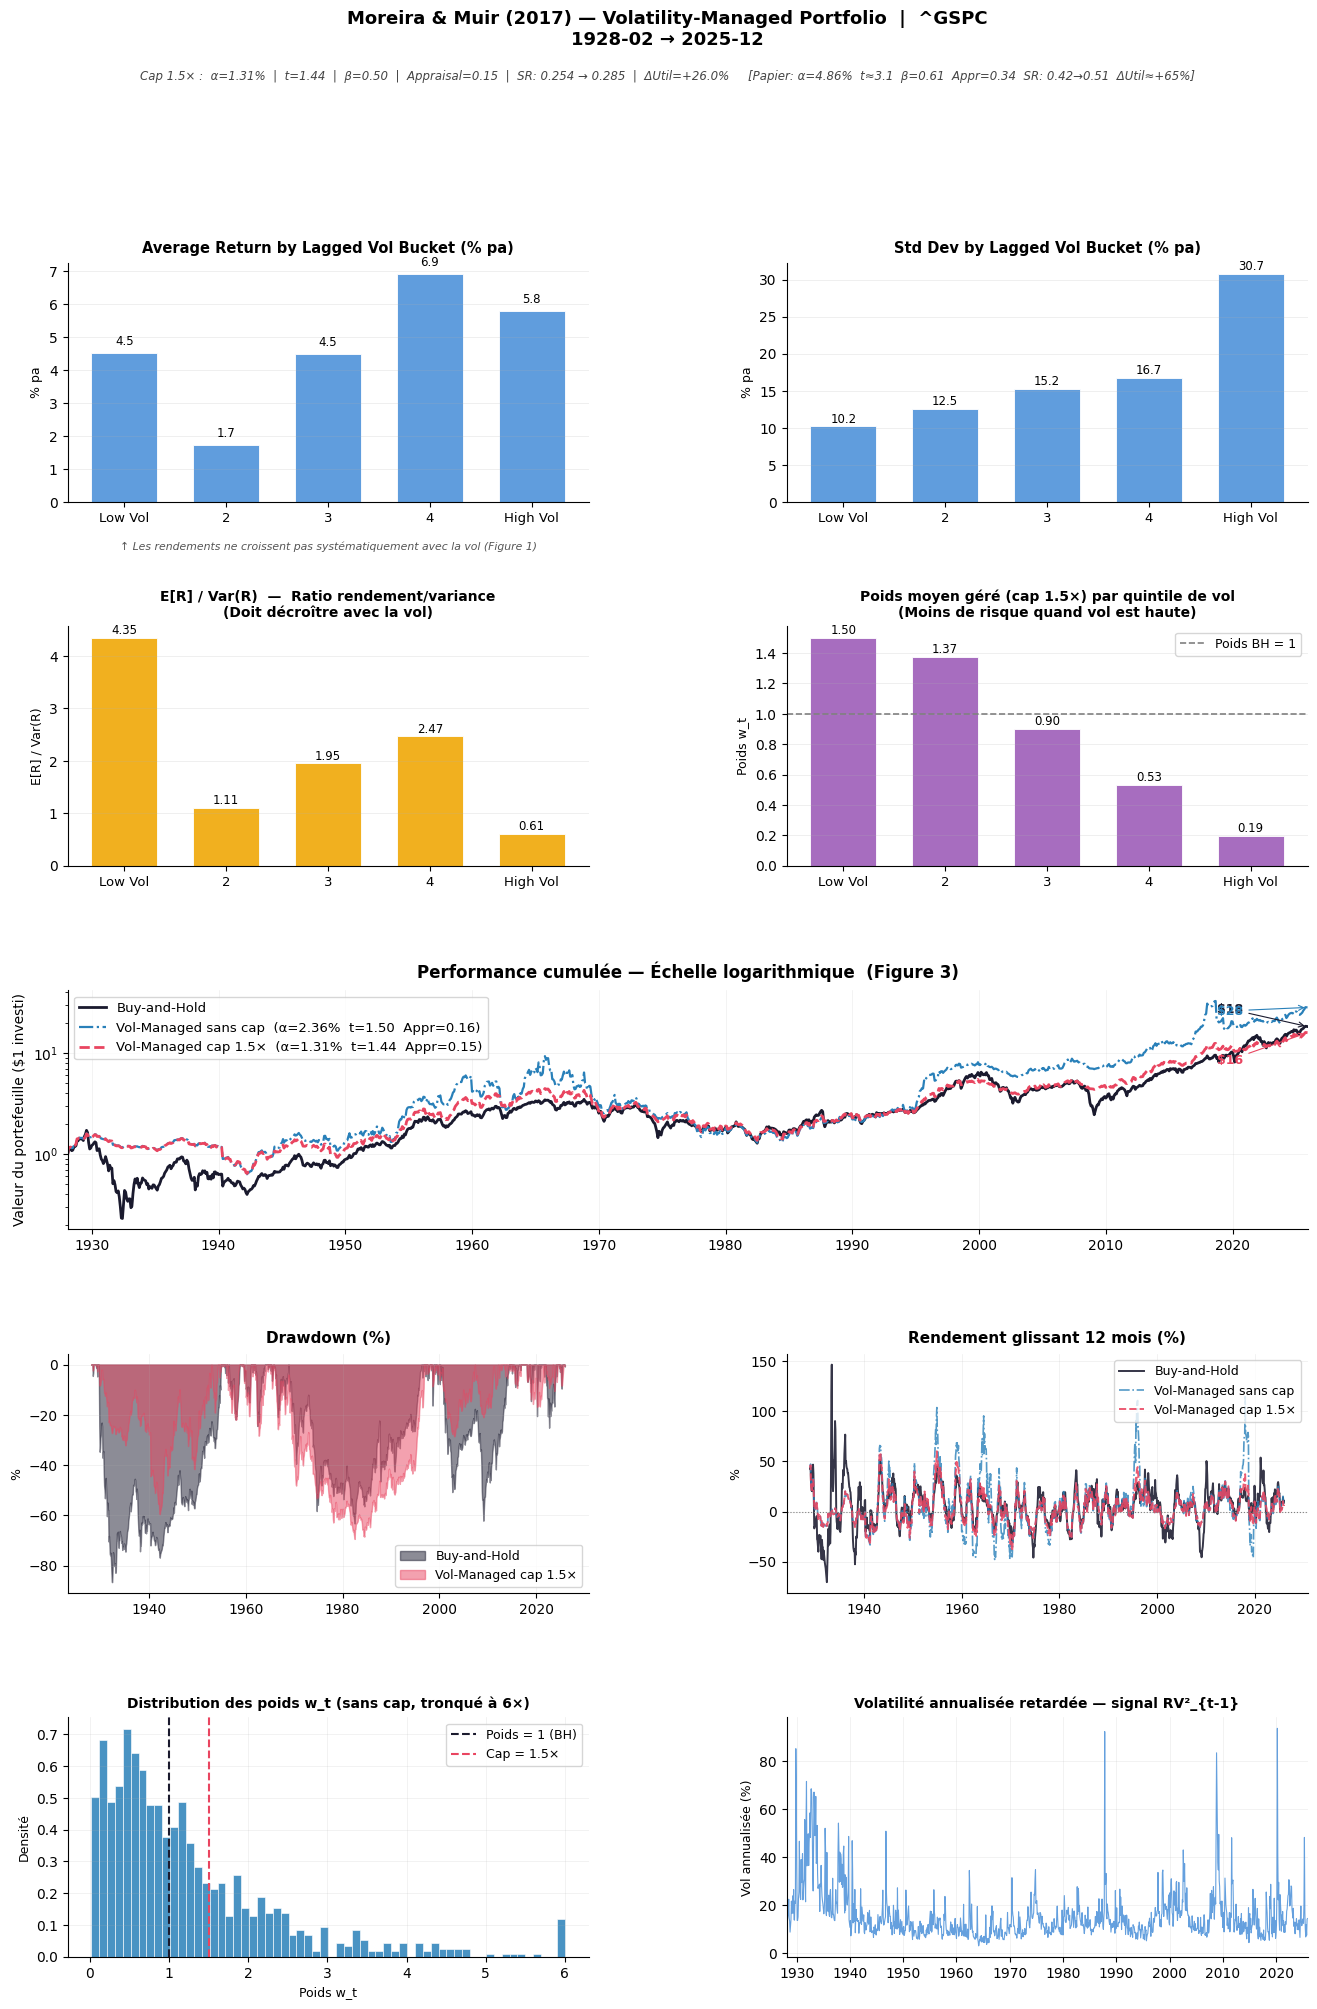

Figure sauvegardée → moreira_muir_2017_replication.png


In [ ]:
# ## 11) Visualisations complètes  (Figures 1 & 3 du papier)
# %%
C_BH   = "#1a1a2e"
C_UNC  = "#2980b9"
C_CAP  = "#e94560"
C_BAR  = "#4a90d9"
C_BAR2 = "#f0a500"
C_WBAR = "#9b59b6"

fig = plt.figure(figsize=(16, 22))
fig.patch.set_facecolor("white")
gs  = gridspec.GridSpec(5, 2, figure=fig, hspace=0.52, wspace=0.38)

bins = ["Low Vol", "2", "3", "4", "High Vol"]
xp   = np.arange(5)


# ── Ligne 0 : Rendement moyen & Écart-type par quintile de vol ───────────────
for ci, (key, title, col, ylabel) in enumerate([
    ("avg_ret", "Average Return by Lagged Vol Bucket (% pa)", C_BAR, "% pa"),
    ("std_dev", "Std Dev by Lagged Vol Bucket (% pa)",        C_BAR, "% pa"),
]):
    ax = fig.add_subplot(gs[0, ci])
    vals = [sort_stats.loc[b, key] if b in sort_stats.index else 0 for b in bins]
    bars = ax.bar(xp, vals, color=col, edgecolor="white", linewidth=0.7,
                  width=0.65, alpha=0.88)
    ax.set_xticks(xp); ax.set_xticklabels(bins, fontsize=9.5)
    ax.set_title(title, fontsize=10.5, fontweight="bold", pad=7)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.28, linewidth=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
                f"{v:.1f}", ha="center", va="bottom", fontsize=8.5)
    if ci == 0:
        ax.text(0.5, -0.20,
                "↑ Les rendements ne croissent pas systématiquement avec la vol (Figure 1)",
                ha="center", transform=ax.transAxes, fontsize=7.8,
                color="#555", style="italic")


# ── Ligne 1 : E[R]/Var(R) & Poids moyen géré ────────────────────────────────
ax = fig.add_subplot(gs[1, 0])
vals = [sort_stats.loc[b, "mv_ratio"] if b in sort_stats.index else 0 for b in bins]
bars = ax.bar(xp, vals, color=C_BAR2, edgecolor="white", linewidth=0.7,
              width=0.65, alpha=0.88)
ax.set_xticks(xp); ax.set_xticklabels(bins, fontsize=9.5)
ax.set_title("E[R] / Var(R)  —  Ratio rendement/variance\n(Doit décroître avec la vol)",
             fontsize=10, fontweight="bold", pad=7)
ax.set_ylabel("E[R] / Var(R)", fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.28, linewidth=0.5)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{v:.2f}", ha="center", va="bottom", fontsize=8.5)

ax = fig.add_subplot(gs[1, 1])
avg_w_bin = monthly.groupby("vol_bin", observed=True)["w_cap"].mean()
vals_w    = [avg_w_bin.get(b, 0) for b in bins]
bars = ax.bar(xp, vals_w, color=C_WBAR, edgecolor="white", linewidth=0.7,
              width=0.65, alpha=0.88)
ax.axhline(1.0, color="grey", ls="--", lw=1.2, label="Poids BH = 1")
ax.set_xticks(xp); ax.set_xticklabels(bins, fontsize=9.5)
ax.set_title(f"Poids moyen géré (cap {CAP}×) par quintile de vol\n"
             "(Moins de risque quand vol est haute)",
             fontsize=10, fontweight="bold", pad=7)
ax.set_ylabel("Poids w_t", fontsize=9)
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.28, linewidth=0.5)
for bar, v in zip(bars, vals_w):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{v:.2f}", ha="center", va="bottom", fontsize=8.5)


# ── Ligne 2 : Performance cumulée — échelle log (Figure 3) ──────────────────
ax5    = fig.add_subplot(gs[2, :])
idx_ts = monthly.index.to_timestamp()

ax5.semilogy(idx_ts, p_bh["wealth"].values,  color=C_BH,  lw=2.0,
             label="Buy-and-Hold")
ax5.semilogy(idx_ts, p_unc["wealth"].values, color=C_UNC, lw=1.6, ls="-.",
             label=(f"Vol-Managed sans cap  "
                    f"(α={reg_unc['alpha_ann']*100:.2f}%  t={reg_unc['t_stat']:.2f}  "
                    f"Appr={reg_unc['appraisal']:.2f})"))
ax5.semilogy(idx_ts, p_cap["wealth"].values, color=C_CAP, lw=2.0, ls="--",
             label=(f"Vol-Managed cap {CAP}×  "
                    f"(α={reg_cap['alpha_ann']*100:.2f}%  t={reg_cap['t_stat']:.2f}  "
                    f"Appr={reg_cap['appraisal']:.2f})"))

ax5.set_title("Performance cumulée — Échelle logarithmique  (Figure 3)",
              fontsize=12, fontweight="bold", pad=9)
ax5.set_ylabel("Valeur du portefeuille ($1 investi)", fontsize=10)
ax5.legend(fontsize=9.5, loc="upper left")
ax5.spines[["top", "right"]].set_visible(False)
ax5.grid(alpha=0.20, linewidth=0.5)
ax5.set_xlim(idx_ts.min(), idx_ts.max())

for W, col, dy in [(p_bh["wealth"],  C_BH,   10),
                   (p_unc["wealth"], C_UNC,  -5),
                   (p_cap["wealth"], C_CAP, -22)]:
    ax5.annotate(
        f"${W.iloc[-1]:,.0f}",
        xy=(idx_ts[-1], W.iloc[-1]),
        xytext=(-65, dy), textcoords="offset points",
        fontsize=9, color=col, fontweight="bold",
        arrowprops=dict(arrowstyle="->", color=col, lw=0.8),
    )


# ── Ligne 3 : Drawdown & Rolling 1 an ───────────────────────────────────────
def drawdown_pct(W):
    return (W - W.cummax()) / W.cummax() * 100

ax6 = fig.add_subplot(gs[3, 0])
ax6.fill_between(idx_ts, drawdown_pct(p_bh["wealth"]).values,  0,
                 alpha=0.50, color=C_BH,  label="Buy-and-Hold")
ax6.fill_between(idx_ts, drawdown_pct(p_cap["wealth"]).values, 0,
                 alpha=0.50, color=C_CAP, label=f"Vol-Managed cap {CAP}×")
ax6.set_title("Drawdown (%)", fontsize=11, fontweight="bold", pad=8)
ax6.set_ylabel("%", fontsize=9)
ax6.legend(fontsize=9)
ax6.spines[["top", "right"]].set_visible(False)
ax6.grid(alpha=0.22, linewidth=0.5)

roll12 = lambda s: (
    s.rolling(12).apply(lambda x: (1+x).prod()-1, raw=True) * 100
)
ax7 = fig.add_subplot(gs[3, 1])
ax7.plot(idx_ts, roll12(monthly["f"]).values,     color=C_BH,  lw=1.4,
         label="Buy-and-Hold", alpha=0.88)
ax7.plot(idx_ts, roll12(monthly["f_unc"]).values, color=C_UNC, lw=1.2, ls="-.",
         label="Vol-Managed sans cap", alpha=0.80)
ax7.plot(idx_ts, roll12(monthly["f_cap"]).values, color=C_CAP, lw=1.4, ls="--",
         label=f"Vol-Managed cap {CAP}×", alpha=0.88)
ax7.axhline(0, color="grey", lw=0.8, ls=":")
ax7.set_title("Rendement glissant 12 mois (%)", fontsize=11, fontweight="bold", pad=8)
ax7.set_ylabel("%", fontsize=9)
ax7.legend(fontsize=9)
ax7.spines[["top", "right"]].set_visible(False)
ax7.grid(alpha=0.22, linewidth=0.5)


# ── Ligne 4 : Distribution des poids & Série temporelle de vol ───────────────
ax8 = fig.add_subplot(gs[4, 0])
ax8.hist(monthly["w_unc"].clip(upper=6), bins=60, color=C_UNC,
         edgecolor="white", linewidth=0.5, alpha=0.85, density=True)
ax8.axvline(1.0, color=C_BH,  ls="--", lw=1.5, label="Poids = 1 (BH)")
ax8.axvline(CAP, color=C_CAP, ls="--", lw=1.5, label=f"Cap = {CAP}×")
ax8.set_title("Distribution des poids w_t (sans cap, tronqué à 6×)",
              fontsize=10, fontweight="bold", pad=7)
ax8.set_xlabel("Poids w_t", fontsize=9)
ax8.set_ylabel("Densité", fontsize=9)
ax8.legend(fontsize=9)
ax8.spines[["top", "right"]].set_visible(False)
ax8.grid(alpha=0.22, linewidth=0.5)

ax9 = fig.add_subplot(gs[4, 1])
ts_vol = np.sqrt(monthly["RV2_lag"] * 12) * 100
ax9.plot(idx_ts, ts_vol.values, color=C_BAR, lw=0.8, alpha=0.85)
ax9.set_title("Volatilité annualisée retardée — signal RV²_{t-1}",
              fontsize=10, fontweight="bold", pad=7)
ax9.set_ylabel("Vol annualisée (%)", fontsize=9)
ax9.spines[["top", "right"]].set_visible(False)
ax9.grid(alpha=0.22, linewidth=0.5)
ax9.set_xlim(idx_ts.min(), idx_ts.max())


# ── Super-titre ──────────────────────────────────────────────────────────────
fig.suptitle(
    f"Moreira & Muir (2017) — Volatility-Managed Portfolio  |  {ASSET_TICKER}\n"
    f"{monthly.index.min()} → {monthly.index.max()}",
    fontsize=13, fontweight="bold", y=0.995,
)
stats_line = (
    f"Cap {CAP}× :  α={reg_cap['alpha_ann']*100:.2f}%  |  t={reg_cap['t_stat']:.2f}  |  "
    f"β={reg_cap['beta']:.2f}  |  Appraisal={reg_cap['appraisal']:.2f}  |  "
    f"SR: {p_bh['sr']:.3f} → {p_cap['sr']:.3f}  |  ΔUtil={dU_cap:+.1f}%     "
    f"[Papier: α=4.86%  t≈3.1  β=0.61  Appr=0.34  SR: 0.42→0.51  ΔUtil≈+65%]"
)
fig.text(0.5, 0.963, stats_line, ha="center", fontsize=8.5,
         color="#444", style="italic")

plt.savefig("moreira_muir_2017_replication.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()
print("Figure sauvegardée → moreira_muir_2017_replication.png")


In [45]:
# ## 12) Tableau récapitulatif final

# %%
print("\n" + "="*70)
print("  RÉSUMÉ — Moreira & Muir (2017)  |  " + ASSET_TICKER)
print("="*70)
print(f"\n  {'Métrique':<40} {'BH':>8} {'VM-unc':>8} {'VM-cap':>8} {'Papier':>10}")
print("  " + "-"*68)

rows = [
    ("Rendement annualisé (%)",   p_bh['ann_ret']*100,  p_unc['ann_ret']*100,  p_cap['ann_ret']*100,  "~8%"),
    ("Volatilité annualisée (%)", p_bh['ann_vol']*100,  p_unc['ann_vol']*100,  p_cap['ann_vol']*100,  "~16%"),
    ("Sharpe ratio",              p_bh['sr'],            p_unc['sr'],            p_cap['sr'],            "0.42→0.51"),
    ("Max Drawdown (%)",          p_bh['max_dd']*100,   p_unc['max_dd']*100,   p_cap['max_dd']*100,   "—"),
    ("Alpha ann. (%)",            "—",                   f"{reg_unc['alpha_ann']*100:.2f}", f"{reg_cap['alpha_ann']*100:.2f}", "4.86"),
    ("t-statistic",               "—",                   f"{reg_unc['t_stat']:.2f}",        f"{reg_cap['t_stat']:.2f}",        "~3.1"),
    ("Beta",                      "—",                   f"{reg_unc['beta']:.3f}",           f"{reg_cap['beta']:.3f}",           "0.61"),
    ("R²",                        "—",                   f"{reg_unc['r2']:.3f}",             f"{reg_cap['r2']:.3f}",             "0.37"),
    ("Appraisal ratio",           "—",                   f"{reg_unc['appraisal']:.3f}",      f"{reg_cap['appraisal']:.3f}",      "0.34"),
    ("ΔUtil MV (%)",              "—",                   f"{dU_unc:+.1f}",                   f"{dU_cap:+.1f}",                   "~+65"),
]

for label, v1, v2, v3, paper in rows:
    def fmt(v): return f"{v:.3f}" if isinstance(v, float) else str(v)
    print(f"  {label:<40} {fmt(v1):>8} {fmt(v2):>8} {fmt(v3):>8} {paper:>10}")

print("\n" + "="*70)

# %%
# Sauvegarde des données mensuelles
out_df = monthly[[
    "f", "RF", "RV2", "RV2_lag",
    "w_unc", "w_cap", "f_unc", "f_cap",
]].copy()
out_df.index = out_df.index.to_timestamp()
out_df.columns = [
    "ret_excess_mensuel", "RF_mensuel", "RV2_courant", "RV2_retarde",
    "poids_sans_cap", "poids_cap",
    "rendement_vm_sans_cap", "rendement_vm_cap",
]
out_df.to_csv("moreira_muir_monthly_results.csv")
print("Données mensuelles sauvegardées → moreira_muir_monthly_results.csv")


  RÉSUMÉ — Moreira & Muir (2017)  |  ^GSPC

  Métrique                                       BH   VM-unc   VM-cap     Papier
  --------------------------------------------------------------------
  Rendement annualisé (%)                     4.692    5.164    3.668        ~8%
  Volatilité annualisée (%)                  18.501   18.501   12.888       ~16%
  Sharpe ratio                                0.254    0.279    0.285  0.42→0.51
  Max Drawdown (%)                          -86.619  -86.083  -69.404          —
  Alpha ann. (%)                                  —     2.36     1.31       4.86
  t-statistic                                     —     1.50     1.44       ~3.1
  Beta                                            —    0.597    0.502       0.61
  R²                                              —    0.356    0.519       0.37
  Appraisal ratio                                 —    0.159    0.147       0.34
  ΔUtil MV (%)                                    —    +21.1    +26.0     